# MNIST Image Denoising using Autoencoder
**Project:** Build a deep learning model that removes noise from images using an Autoencoder on MNIST

### What we will do:
1. Load MNIST dataset
2. Add Gaussian noise to images
3. Train 3 Autoencoder models (FFNN, Transpose CNN, Upsampled CNN)
4. Visualize original vs noisy vs denoised images

## Step 1: Import Libraries

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)



cuda


## Step 2: Load MNIST Dataset

In [2]:
transform = transforms.ToTensor()

# Download MNIST
full_train = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_data, val_data = random_split(full_train, [48000, 12000])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

print(f'Train size: {len(train_data)}')
print(f'Validation size: {len(val_data)}')
print(f'Test size: {len(test_data)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 473kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.60MB/s]

Train size: 48000
Validation size: 12000
Test size: 10000


## Step 3: Visualize Sample Images

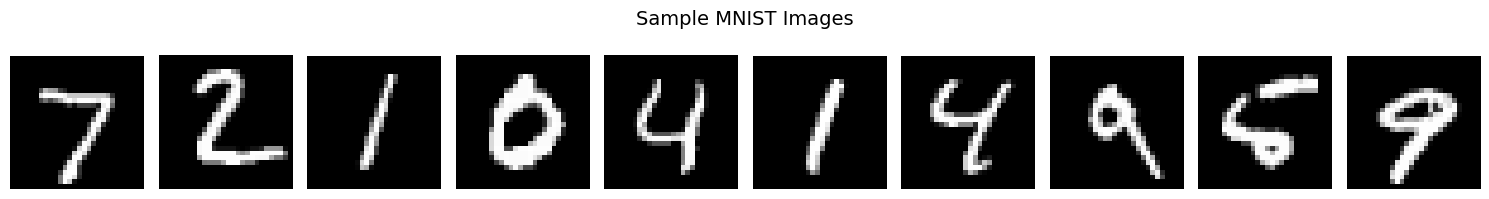

In [3]:
sample_imgs, _ = next(iter(test_loader))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(sample_imgs[i].squeeze(), cmap='gray')
    axes[i].axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

## Step 4: Add Noise to Images

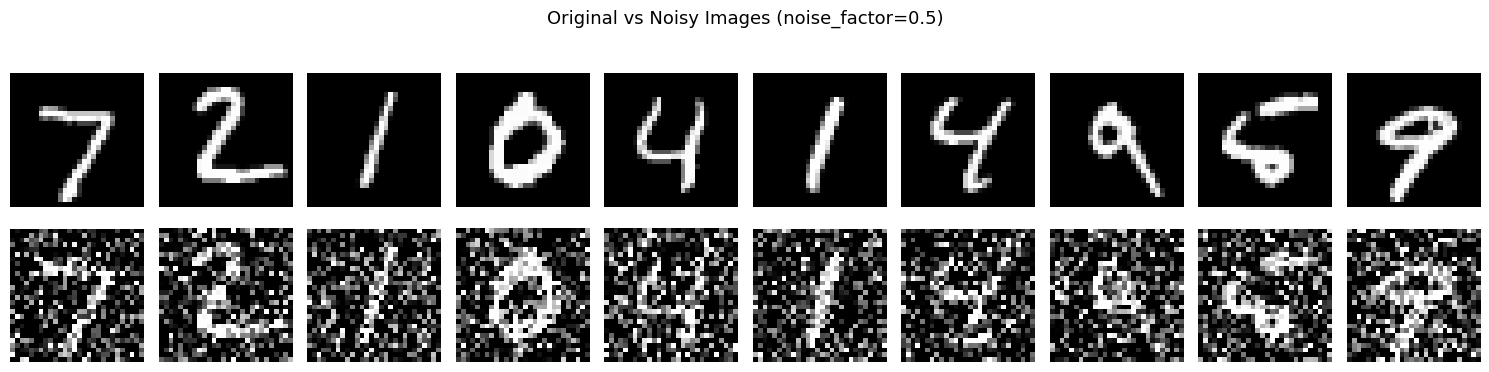

In [4]:
def add_noise(images, noise_factor=0.5):
    """Add Gaussian noise to images"""
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0., 1.)

# Visualize: Original vs Noisy
noisy_samples = add_noise(sample_imgs)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    axes[0, i].imshow(sample_imgs[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(noisy_samples[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Noisy', fontsize=12)
plt.suptitle('Original vs Noisy Images (noise_factor=0.5)', fontsize=13)
plt.tight_layout()
plt.show()


## MODEL 1: FFNN Autoencoder (Fully Connected / Linear Layers)

In [7]:
class FFNNAutoencoder(nn.Module):
    def __init__(self):
        super(FFNNAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

        # Weight initialization
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                n = m.weight.size(1)
                std = 1.0 / np.sqrt(n)
                nn.init.normal_(m.weight, 0, std)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.view(-1, 28*28)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.view(-1, 1, 28, 28)

ffnn_model = FFNNAutoencoder().to(device)
print('FFNN Autoencoder Architecture:')
print(ffnn_model)

FFNN Autoencoder Architecture:
FFNNAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


## MODEL 2: Transpose CNN Autoencoder

In [8]:
class TransposeConvAutoencoder(nn.Module):
    def __init__(self):
        super(TransposeConvAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 16, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

tconv_model = TransposeConvAutoencoder().to(device)
print('Transpose CNN Autoencoder Architecture:')
print(tconv_model)

Transpose CNN Autoencoder Architecture:
TransposeConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)


## MODEL 3: Upsampled CNN Autoencoder

In [9]:
class UpsampledConvAutoencoder(nn.Module):
    def __init__(self):
        super(UpsampledConvAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(4, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

upsamp_model = UpsampledConvAutoencoder().to(device)
print('Upsampled CNN Autoencoder Architecture:')
print(upsamp_model)

Upsampled CNN Autoencoder Architecture:
UpsampledConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU()
    (3): Upsample(scale_factor=2.0, mode='nearest')
    (4): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)



## Step 5: Training Function

In [10]:
def train_model(model, model_name, num_epochs=20, noise_factor=0.5, lr=0.001):
    criterion = nn.MSELoss()  # Compare pixel values
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses   = []

    print(f'\n Training {model_name}')
    print('-' * 50)

    for epoch in range(num_epochs):
        # Training
        model.train()
        total_train_loss = 0

        for images, _ in train_loader:
            images = images.to(device)
            noisy_images = add_noise(images, noise_factor).to(device)

            outputs = model(noisy_images)          # Reconstruct from noisy
            loss = criterion(outputs, images)      # Compare with clean original

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(device)
                noisy_images = add_noise(images, noise_factor).to(device)
                outputs = model(noisy_images)
                loss = criterion(outputs, images)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:02d}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    print(f'{model_name} Training Complete!')
    return train_losses, val_losses

## Step 6: Train All 3 Models (20 epochs each)

In [11]:
NUM_EPOCHS = 20
NOISE_FACTOR = 0.5

# Train Model 1: FFNN
ffnn_train_loss, ffnn_val_loss = train_model(ffnn_model, 'FFNN Autoencoder', NUM_EPOCHS, NOISE_FACTOR)


 Training FFNN Autoencoder
--------------------------------------------------
Epoch [01/20] | Train Loss: 0.0487 | Val Loss: 0.0340
Epoch [05/20] | Train Loss: 0.0247 | Val Loss: 0.0245
Epoch [10/20] | Train Loss: 0.0211 | Val Loss: 0.0211
Epoch [15/20] | Train Loss: 0.0198 | Val Loss: 0.0200
Epoch [20/20] | Train Loss: 0.0189 | Val Loss: 0.0191
FFNN Autoencoder Training Complete!


In [12]:
# Train Model 2: Transpose CNN
tconv_train_loss, tconv_val_loss = train_model(tconv_model, 'Transpose CNN Autoencoder', NUM_EPOCHS, NOISE_FACTOR)


 Training Transpose CNN Autoencoder
--------------------------------------------------
Epoch [01/20] | Train Loss: 0.0868 | Val Loss: 0.0515
Epoch [05/20] | Train Loss: 0.0360 | Val Loss: 0.0359
Epoch [10/20] | Train Loss: 0.0343 | Val Loss: 0.0343
Epoch [15/20] | Train Loss: 0.0331 | Val Loss: 0.0331
Epoch [20/20] | Train Loss: 0.0320 | Val Loss: 0.0321
Transpose CNN Autoencoder Training Complete!


In [14]:
# Train Model 3: Upsampled CNN
upsamp_train_loss, upsamp_val_loss = train_model(upsamp_model, 'Upsampled CNN Autoencoder', NUM_EPOCHS, NOISE_FACTOR)


 Training Upsampled CNN Autoencoder
--------------------------------------------------
Epoch [01/20] | Train Loss: 0.0165 | Val Loss: 0.0165
Epoch [05/20] | Train Loss: 0.0163 | Val Loss: 0.0164
Epoch [10/20] | Train Loss: 0.0162 | Val Loss: 0.0162
Epoch [15/20] | Train Loss: 0.0160 | Val Loss: 0.0160
Epoch [20/20] | Train Loss: 0.0159 | Val Loss: 0.0160
Upsampled CNN Autoencoder Training Complete!


## Step 7: Plot Training & Validation Loss

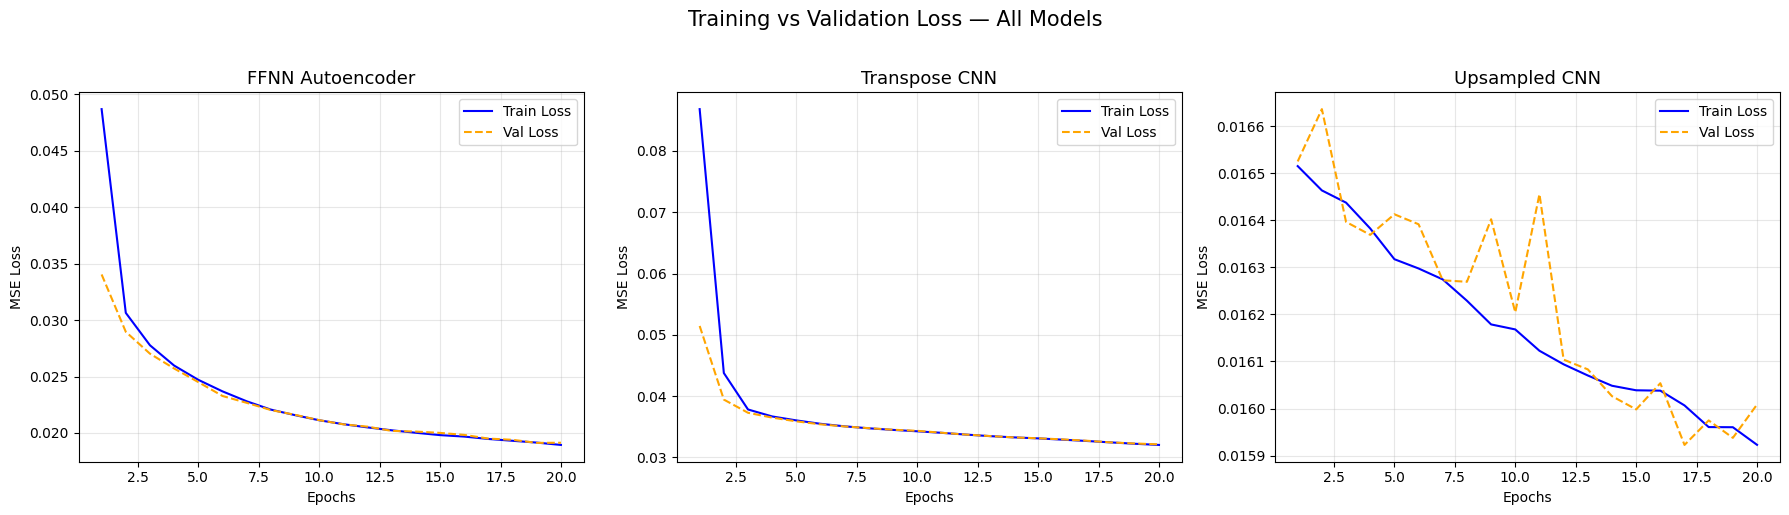

In [15]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_data = [
    ('FFNN Autoencoder', ffnn_train_loss, ffnn_val_loss),
    ('Transpose CNN', tconv_train_loss, tconv_val_loss),
    ('Upsampled CNN', upsamp_train_loss, upsamp_val_loss),
]

for ax, (name, train_l, val_l) in zip(axes, models_data):
    ax.plot(epochs_range, train_l, label='Train Loss', color='blue')
    ax.plot(epochs_range, val_l,   label='Val Loss',   color='orange', linestyle='--')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Loss — All Models', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Step 8: Visualize Results — Original vs Noisy vs Denoised

In [16]:
def visualize_results(model, model_name, noise_factor=0.5, n=10):
    model.eval()
    test_imgs, _ = next(iter(test_loader))
    test_imgs = test_imgs.to(device)
    noisy_imgs = add_noise(test_imgs, noise_factor).to(device)

    with torch.no_grad():
        outputs = model(noisy_imgs)

    test_imgs  = test_imgs.cpu()
    noisy_imgs = noisy_imgs.cpu()
    outputs    = outputs.cpu()

    fig, axes = plt.subplots(3, n, figsize=(16, 5))

    for i in range(n):
        # Original
        axes[0, i].imshow(test_imgs[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        # Noisy
        axes[1, i].imshow(noisy_imgs[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
        # Denoised
        axes[2, i].imshow(outputs[i].squeeze(), cmap='gray')
        axes[2, i].axis('off')

    axes[0, 0].set_ylabel('Original', fontsize=11, labelpad=40)
    axes[1, 0].set_ylabel('Noisy',    fontsize=11, labelpad=40)
    axes[2, 0].set_ylabel('Denoised', fontsize=11, labelpad=40)

    plt.suptitle(f'{model_name} — Denoising Results', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

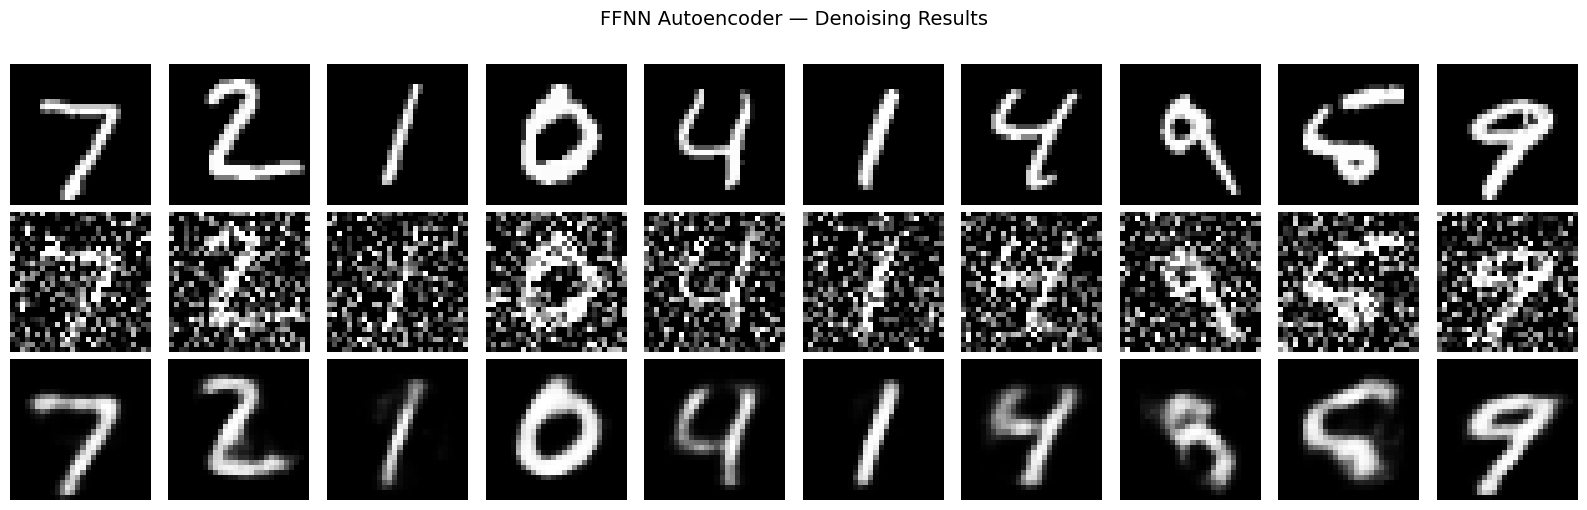

In [17]:
# Model 1 Results
visualize_results(ffnn_model, 'FFNN Autoencoder')

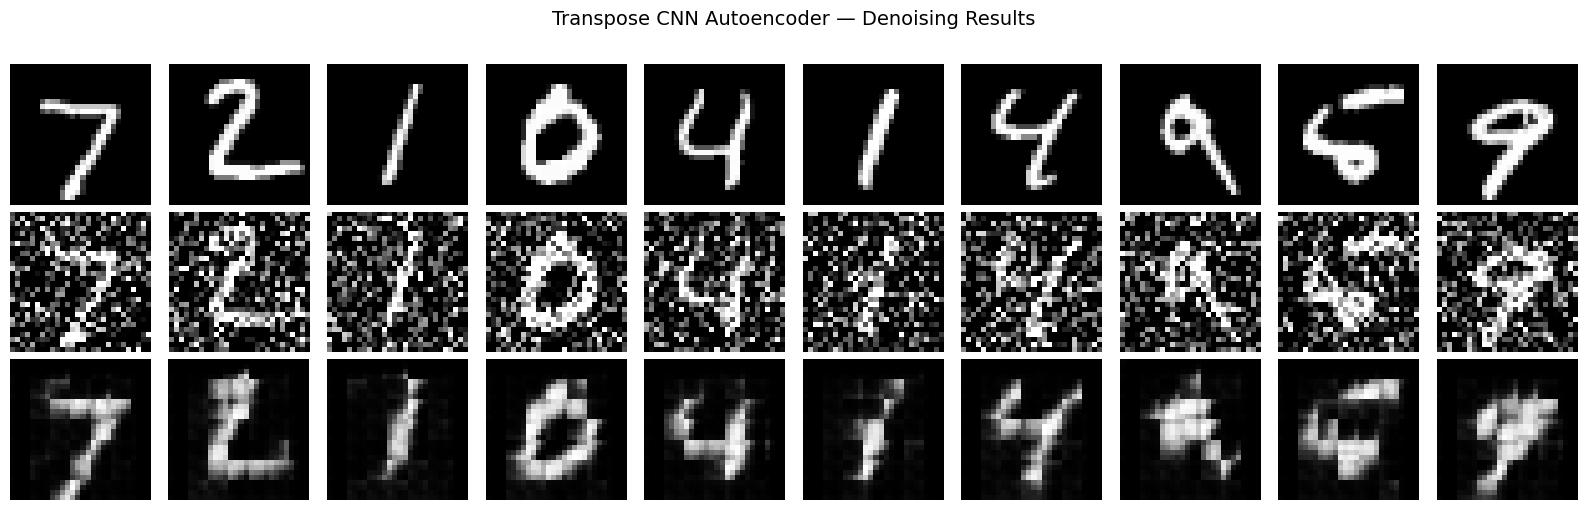

In [18]:
# Model 2 Results
visualize_results(tconv_model, 'Transpose CNN Autoencoder')

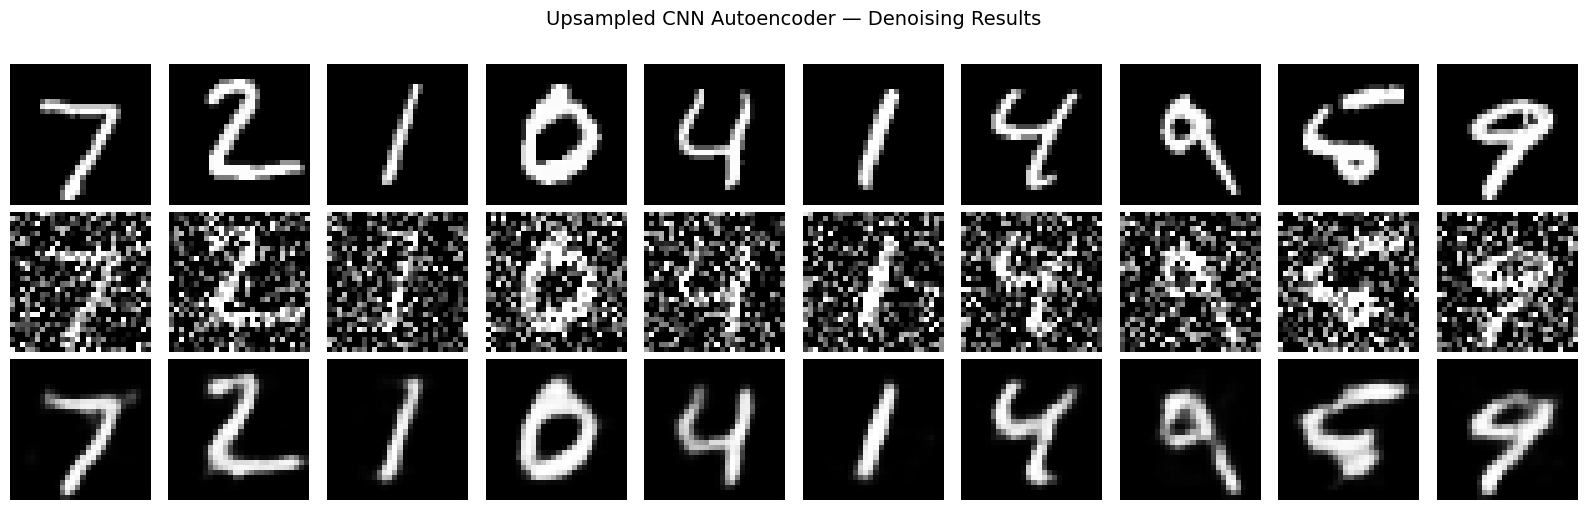

In [19]:
# Model 3 Results
visualize_results(upsamp_model, 'Upsampled CNN Autoencoder')

## Step 9: Save Trained Models

In [20]:
torch.save(ffnn_model.state_dict(),    'F_Auto_MNIST_model.pth')
torch.save(tconv_model.state_dict(),   'Tran_conv_Auto_MNIST_model.pth')
torch.save(upsamp_model.state_dict(),  'upsamp_conv_Auto_MNIST_model.pth')

print('All 3 models saved successfully')
print('F_Auto_MNIST_model.pth')
print('Tran_conv_Auto_MNIST_model.pth')
print('upsamp_conv_Auto_MNIST_model.pth')

All 3 models saved successfully
F_Auto_MNIST_model.pth
Tran_conv_Auto_MNIST_model.pth
upsamp_conv_Auto_MNIST_model.pth


## Step 10: Final Comparison — All 3 Models Side by Side

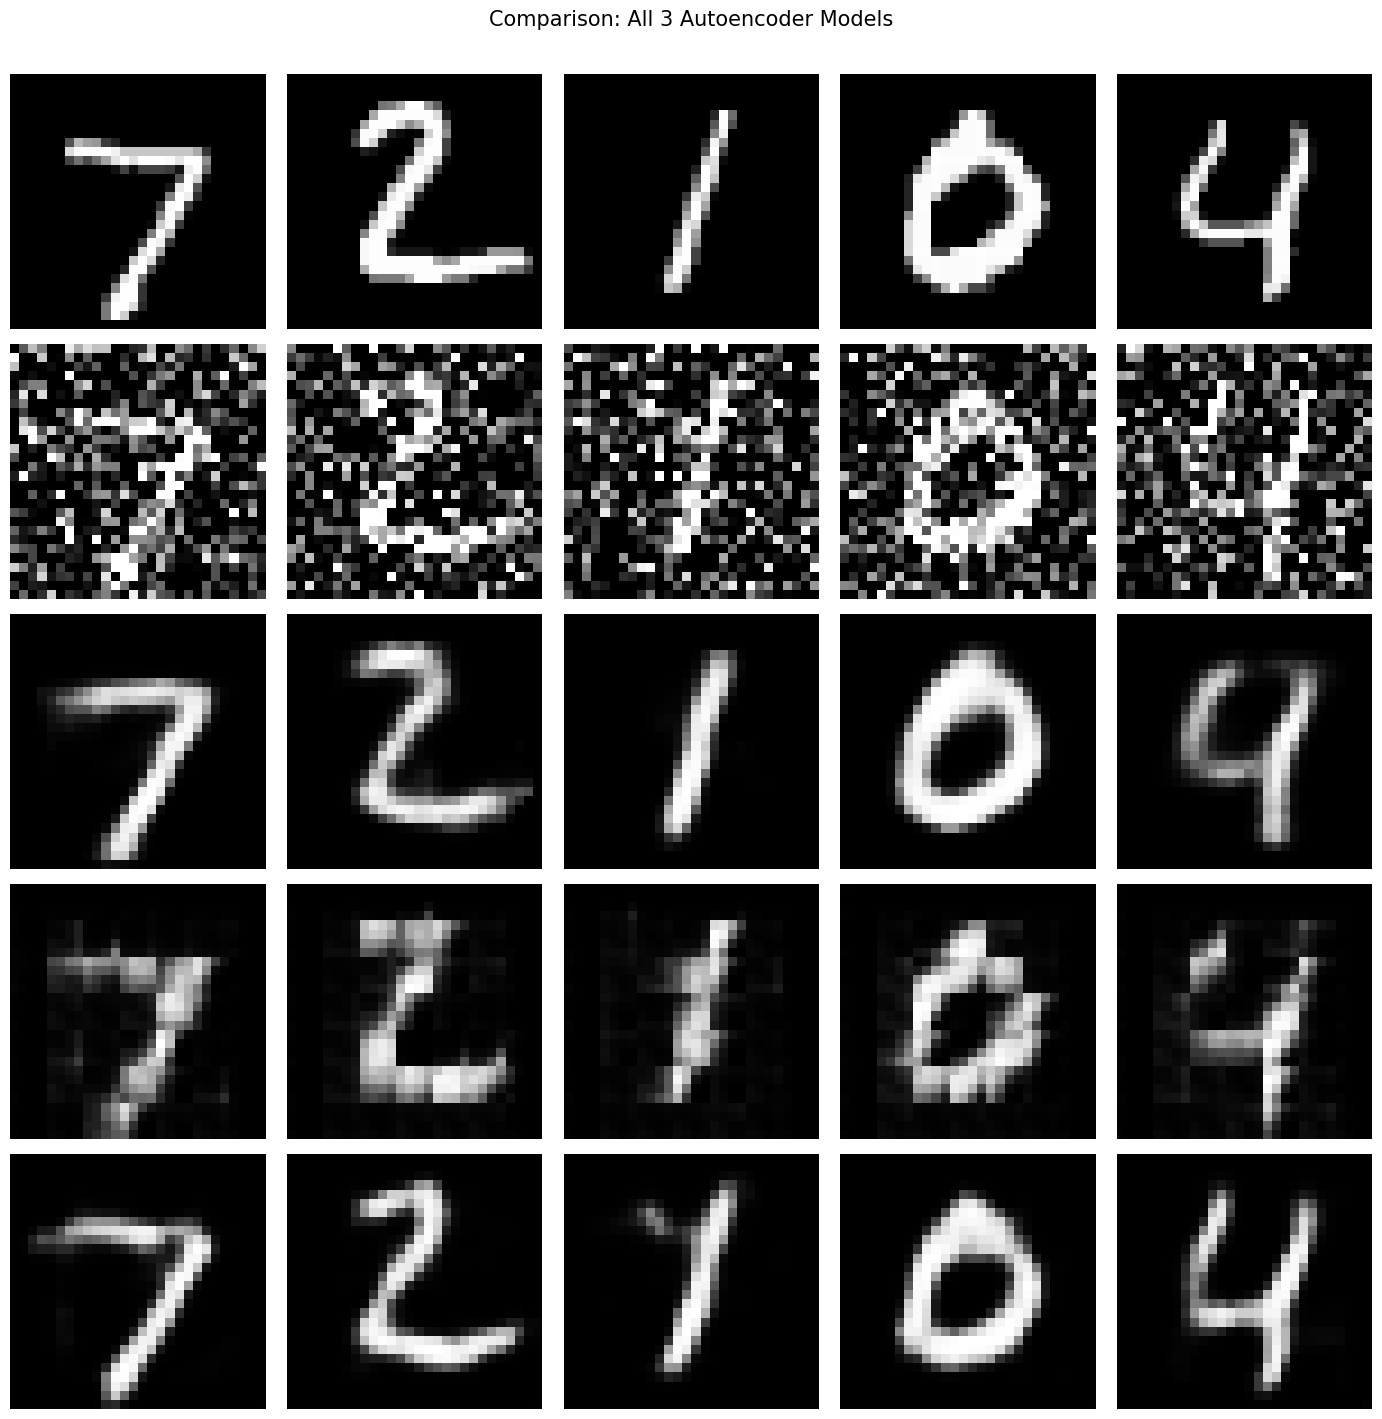

In [21]:
# Pick same 5 test images for fair comparison
test_imgs, _ = next(iter(test_loader))
test_imgs = test_imgs[:5].to(device)
noisy_imgs = add_noise(test_imgs).to(device)

models_list = [
    (ffnn_model,   'FFNN'),
    (tconv_model,  'Transpose CNN'),
    (upsamp_model, 'Upsampled CNN'),
]

fig, axes = plt.subplots(5, 5, figsize=(14, 14))
row_labels = ['Original', 'Noisy', 'FFNN\nDenoised', 'Transpose CNN\nDenoised', 'Upsampled CNN\nDenoised']

for col in range(5):
    # Row 0: Original
    axes[0, col].imshow(test_imgs[col].cpu().squeeze(), cmap='gray')
    axes[0, col].axis('off')
    # Row 1: Noisy
    axes[1, col].imshow(noisy_imgs[col].cpu().squeeze(), cmap='gray')
    axes[1, col].axis('off')
    # Rows 2-4: Each model output
    for row, (model, _) in enumerate(models_list):
        model.eval()
        with torch.no_grad():
            out = model(noisy_imgs[col].unsqueeze(0))
        axes[row+2, col].imshow(out.cpu().squeeze(), cmap='gray')
        axes[row+2, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=11, labelpad=50, rotation=0, va='center')

plt.suptitle('Comparison: All 3 Autoencoder Models', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---
## Summary

| Model | Architecture | Compressed Size | Notes |
|-------|-------------|-----------------|-------|
| FFNN Autoencoder | Linear layers only | 32 units | Simple, fast |
| Transpose CNN | Conv + ConvTranspose2d | 4×7×7 = 196 | May have checkerboard artifacts |
| Upsampled CNN | Conv + Upsample + Conv | 4×7×7 = 196 | Cleaner output, no artifacts |

**Loss Function:** MSE (Mean Squared Error) — compares pixel values  
**Optimizer:** Adam (lr=0.001)  
**Epochs:** 20  
**Train/Val Split:** 48,000 / 12,000  
**Noise Factor:** 0.5 (Gaussian noise)